In [40]:
import sys
sys.path.insert(0, '..')

In [41]:
# Basic imports
import jax.numpy as np
import jax.random as jr
import jax.scipy as jsp
import jax
import numpy

jax.config.update("jax_enable_x64", True)

import glob
import interpax as ipx

from sklearn.cluster import KMeans, DBSCAN
from sklearn.decomposition import PCA


# Optimisation imports
import zodiax as zdx
import optax
import optimistix as optx

# dLux imports
import dLux as dl
import dLux.utils as dlu

# Visualisation imports
from tqdm.auto import tqdm
import matplotlib.pyplot as plt
import matplotlib

%matplotlib inline
plt.rcParams['image.cmap'] = 'inferno'
plt.rcParams["font.family"] = "serif"
plt.rcParams["image.origin"] = 'lower'
plt.rcParams['figure.dpi'] = 72
plt.rcParams["font.size"] = 24

from detectors import *
from apertures import *
from models import *
from fisher import *
from stats import posterior
from fitting import *
from plotting import *
from spectra import *

import jax.tree_util as jtu
import interpax as ipx

def set_array(pytree):
    dtype = np.float64 if jax.config.x64_enabled else np.float32
    floats, other = eqx.partition(pytree, eqx.is_inexact_array_like)
    floats = jtu.tree_map(lambda x: np.array(x, dtype=dtype), floats)
    return eqx.combine(floats, other)


In [42]:
files = glob.glob("../batch/breathing-data/params/*.npz")

In [43]:
mjds = []
despaces = []
zernikes = []
dzernikes = []
ddespaces = []
coldmasks = []
fluxes = []
dfluxes = []

for f in files:
    res = numpy.load(f, allow_pickle=True)
    mjds.append(res["mjd"][()])
    despaces.append(list(res["params"][()]["despace"].values())[0])
    zernikes.append(list(res["params"][()]["aberrations"].values())[0])
    dzernikes.append(list(res["uncertainty"][()]["aberrations"].values())[0])
    ddespaces.append(list(res["uncertainty"][()]["despace"].values())[0])
    coldmasks.append(list(res["params"][()]["cold_mask_shift"].values())[0])
    fluxes.append(list(res["params"][()]["spectrum"].values())[0])
    dfluxes.append(list(res["uncertainty"][()]["spectrum"].values())[0])

mjds = np.array(mjds)
despaces = np.array(despaces)
zernikes = np.array(zernikes)
dzernikes = np.array(dzernikes)

ddespaces = np.array(ddespaces)
coldmasks = np.array(coldmasks)
fluxes = 10**np.array(fluxes)
dfluxes = fluxes * np.log(10)* np.array(dfluxes)

In [44]:
nc = 18
kmeans = KMeans(n_clusters=nc, random_state=0).fit(np.reshape(mjds, (-1, 1)))
idx = numpy.argsort(kmeans.cluster_centers_.sum(axis=1))
lut = numpy.zeros_like(idx)
lut[idx] = numpy.arange(nc)

clumps = lut[kmeans.labels_]


In [45]:
np.diff(np.sort(kmeans.cluster_centers_.sum(axis=1)))

Array([6.41074564e-02, 6.69319697e-02, 6.62456792e-02, 1.75197274e+01,
       6.17396850e-02, 6.81347247e-02, 6.58812126e-02, 1.54499615e+01,
       6.66639128e-02, 6.52695852e+00, 6.51824411e-02, 6.65972331e-02,
       6.66462177e-02, 7.74611703e+01, 6.51137697e-02, 6.71337833e-02,
       6.65827256e-02], dtype=float64)

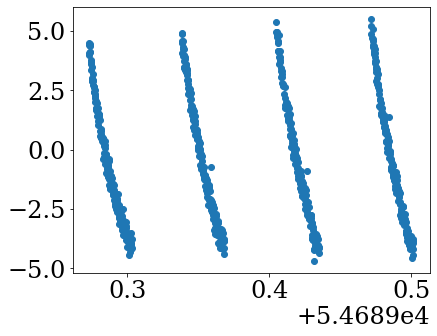

In [46]:
valid = (clumps >= 14) & (clumps < 19)
plt.scatter(mjds[valid], despaces[valid])

(-11.0, 6.5)

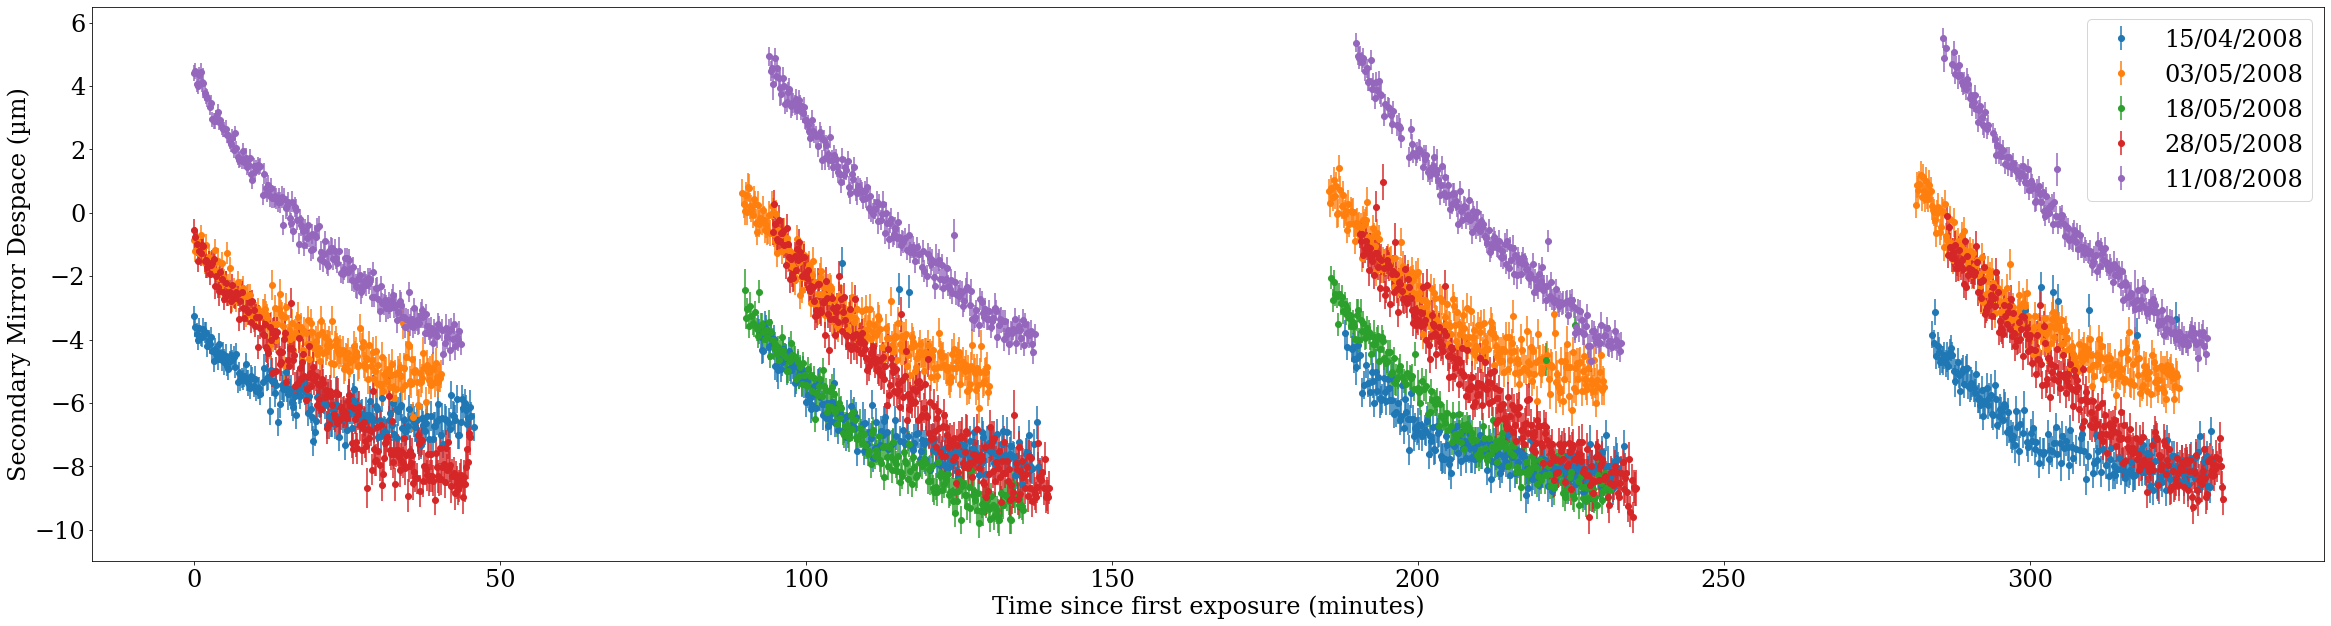

In [47]:
plt.figure(figsize=(40,10))

save_data = []

idxs = [0, 4, 8, 10, 14, 18]

for i in range(5):
    valid = (clumps >= idxs[i]) & (clumps < idxs[i+1])

    fudge = 90 if i == 2 else 0

    plt.errorbar((mjds[valid]-np.min(mjds[valid]))*60*24 + fudge, despaces[valid], yerr=ddespaces[valid], fmt='o')
    save_data.append({"time":(mjds[valid]-np.min(mjds[valid]))*60*24 + fudge, "despace":despaces[valid], "err": ddespaces[valid]})

plt.legend(['15/04/2008', '03/05/2008', '18/05/2008', '28/05/2008', '11/08/2008'])

plt.xlabel("Time since first exposure (minutes)")
plt.ylabel("Secondary Mirror Despace (µm)")
plt.ylim(-11, 6.5)

In [48]:
np.save("defocus_plot.npy", save_data)

Text(0, 0.5, 'Flux')

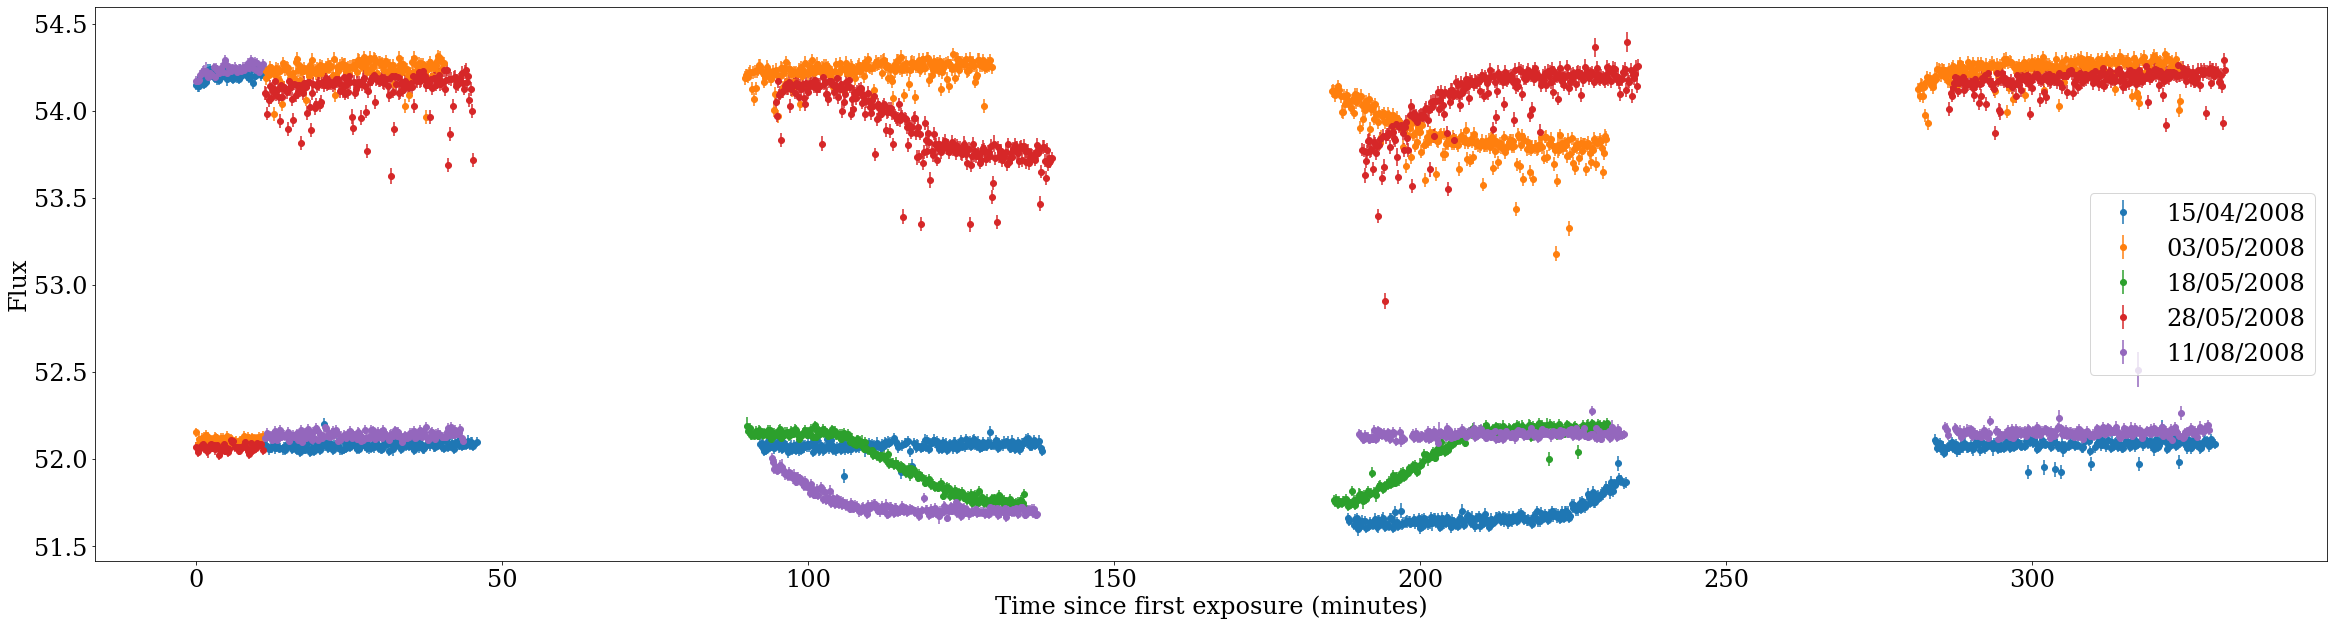

In [49]:
plt.figure(figsize=(40,10))

idxs = [0, 4, 8, 10, 14, 18]

save_data = []

for i in range(5):
    valid = (clumps >= idxs[i]) & (clumps < idxs[i+1])

    fudge = 90 if i == 2 else 0

    plt.errorbar((mjds[valid]-np.min(mjds[valid]))*60*24 + fudge, fluxes[valid], yerr=dfluxes[valid], fmt='o')

    save_data.append({"time":(mjds[valid]-np.min(mjds[valid]))*60*24 + fudge, "flux":fluxes[valid], "err": dfluxes[valid]})

plt.legend(['15/04/2008', '03/05/2008', '18/05/2008', '28/05/2008', '11/08/2008'])

plt.xlabel("Time since first exposure (minutes)")
plt.ylabel("Flux")


Text(0, 0.5, 'defocus')

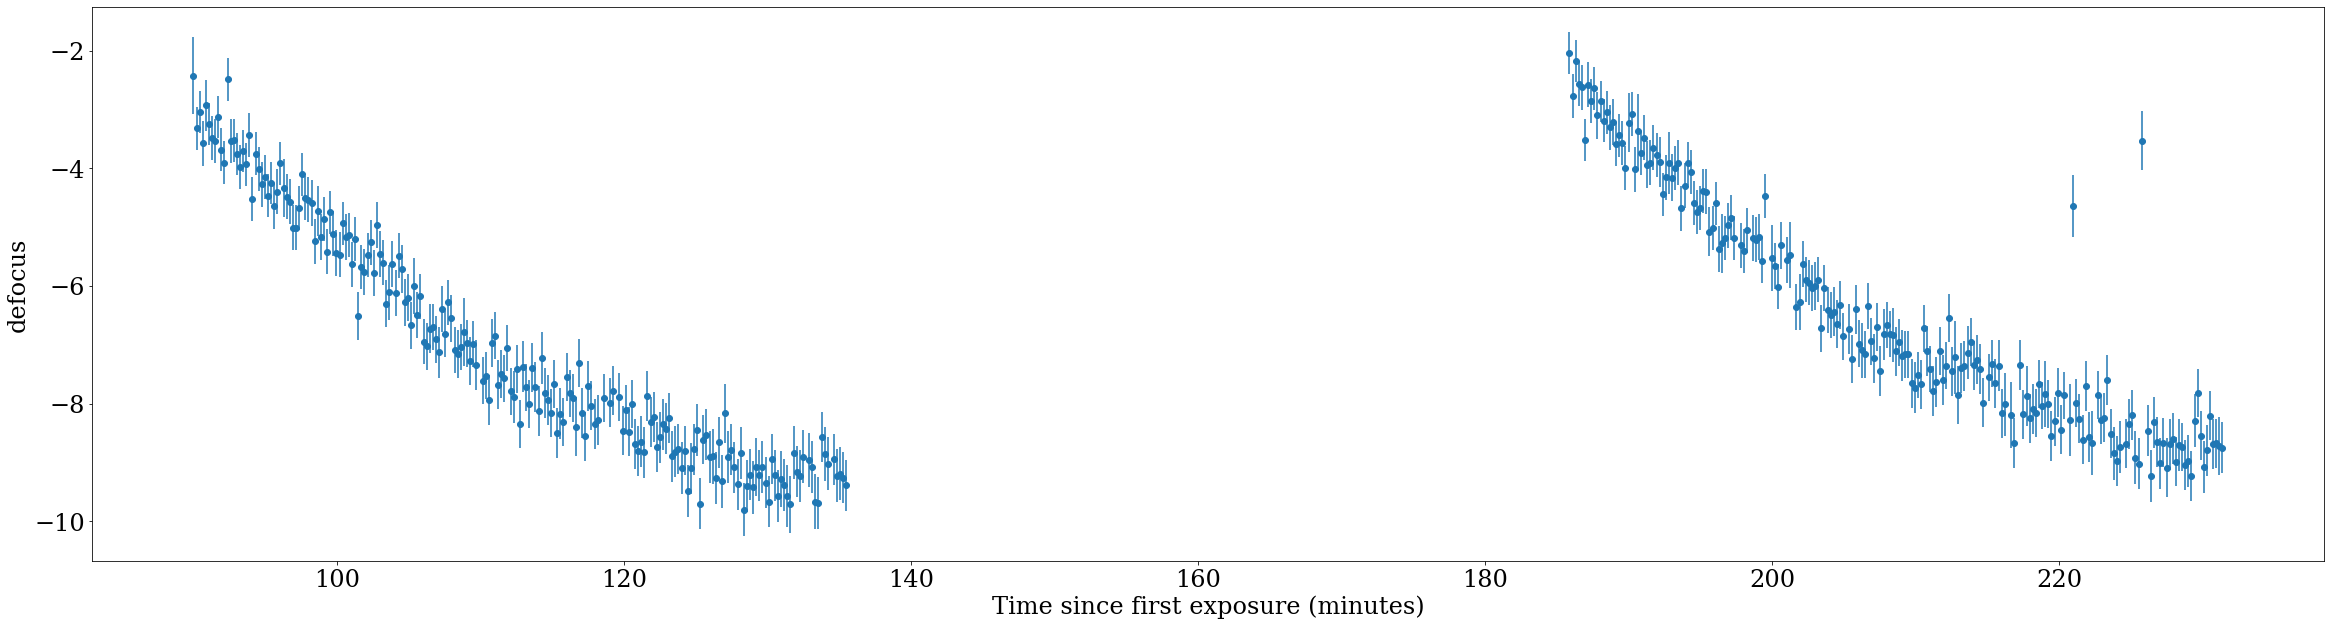

In [50]:
save_data = np.load("defocus_plot.npy", allow_pickle=True)
plt.figure(figsize=(40,10))

i=2
plt.errorbar(save_data[i]["time"], save_data[i]["despace"], save_data[i]["err"], fmt='o')

#plt.legend(['15/04/2008', '03/05/2008', '18/05/2008', '28/05/2008', '11/08/2008'])

plt.xlabel("Time since first exposure (minutes)")
plt.ylabel("defocus")


In [51]:
np.save("transit_plot.npy", save_data)

Text(0, 0.5, 'Astig Y (nm)')

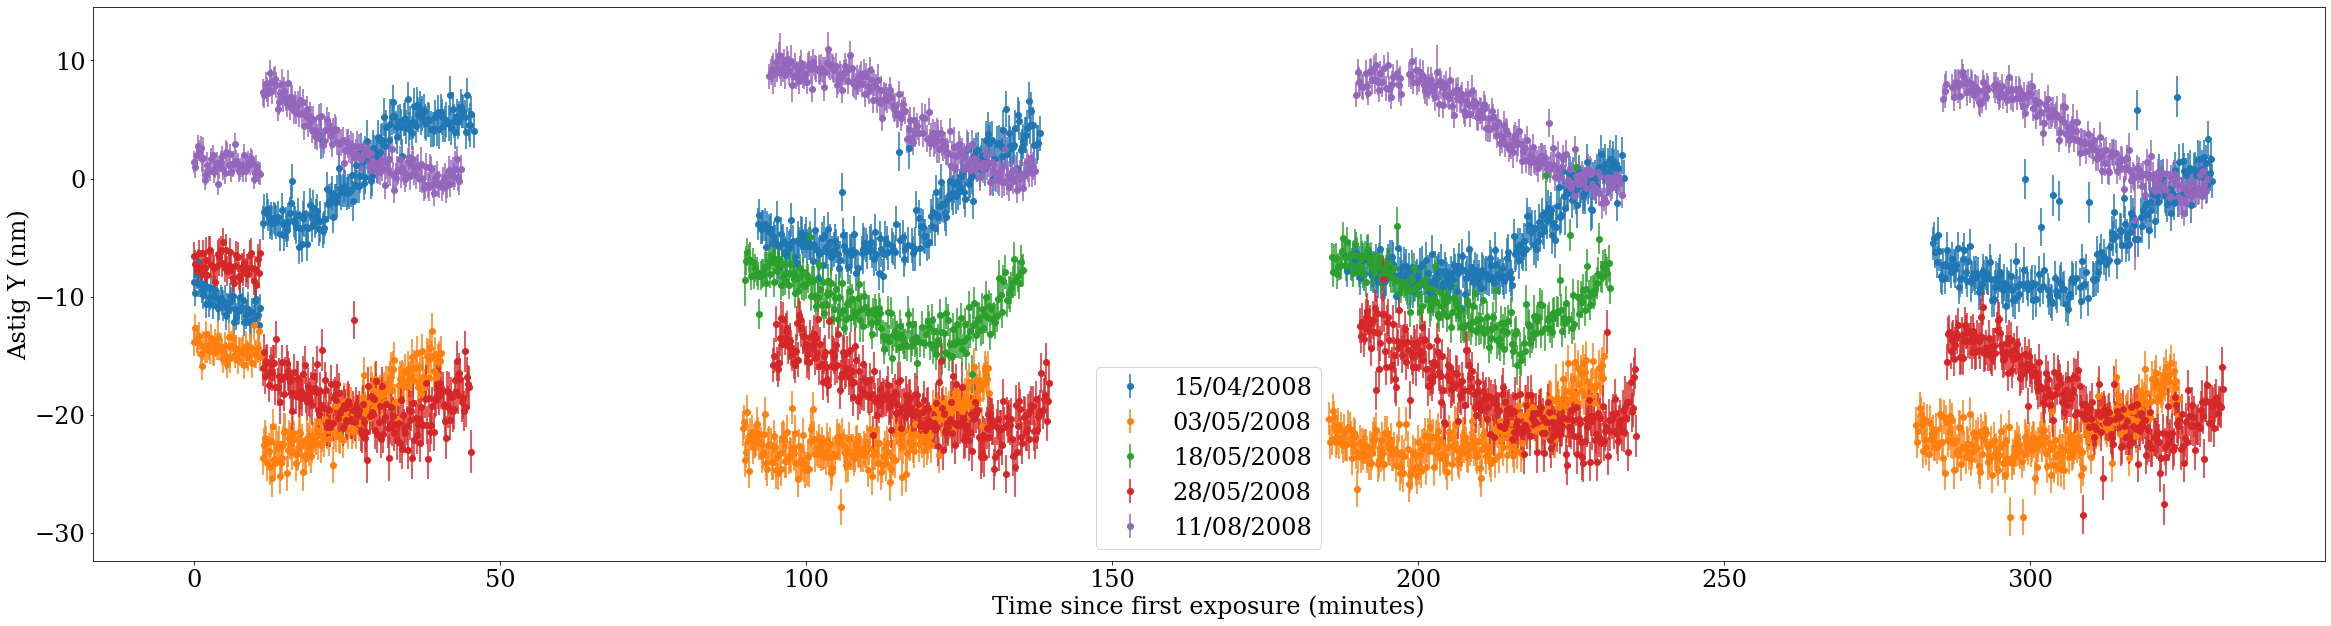

In [52]:
plt.figure(figsize=(40,10))
index = 1
idxs = [0, 4, 8, 10, 14, 18]
for i in range(5):
    valid = (clumps >= idxs[i]) & (clumps < idxs[i+1])

    fudge = 90 if i == 2 else 0

    plt.errorbar((mjds[valid]-np.min(mjds[valid]))*60*24 + fudge, zernikes[valid,index], yerr=dzernikes[valid,index], fmt='o')

plt.legend(['15/04/2008', '03/05/2008', '18/05/2008', '28/05/2008', '11/08/2008'])
plt.xlabel("Time since first exposure (minutes)")
plt.ylabel("Astig Y (nm)")


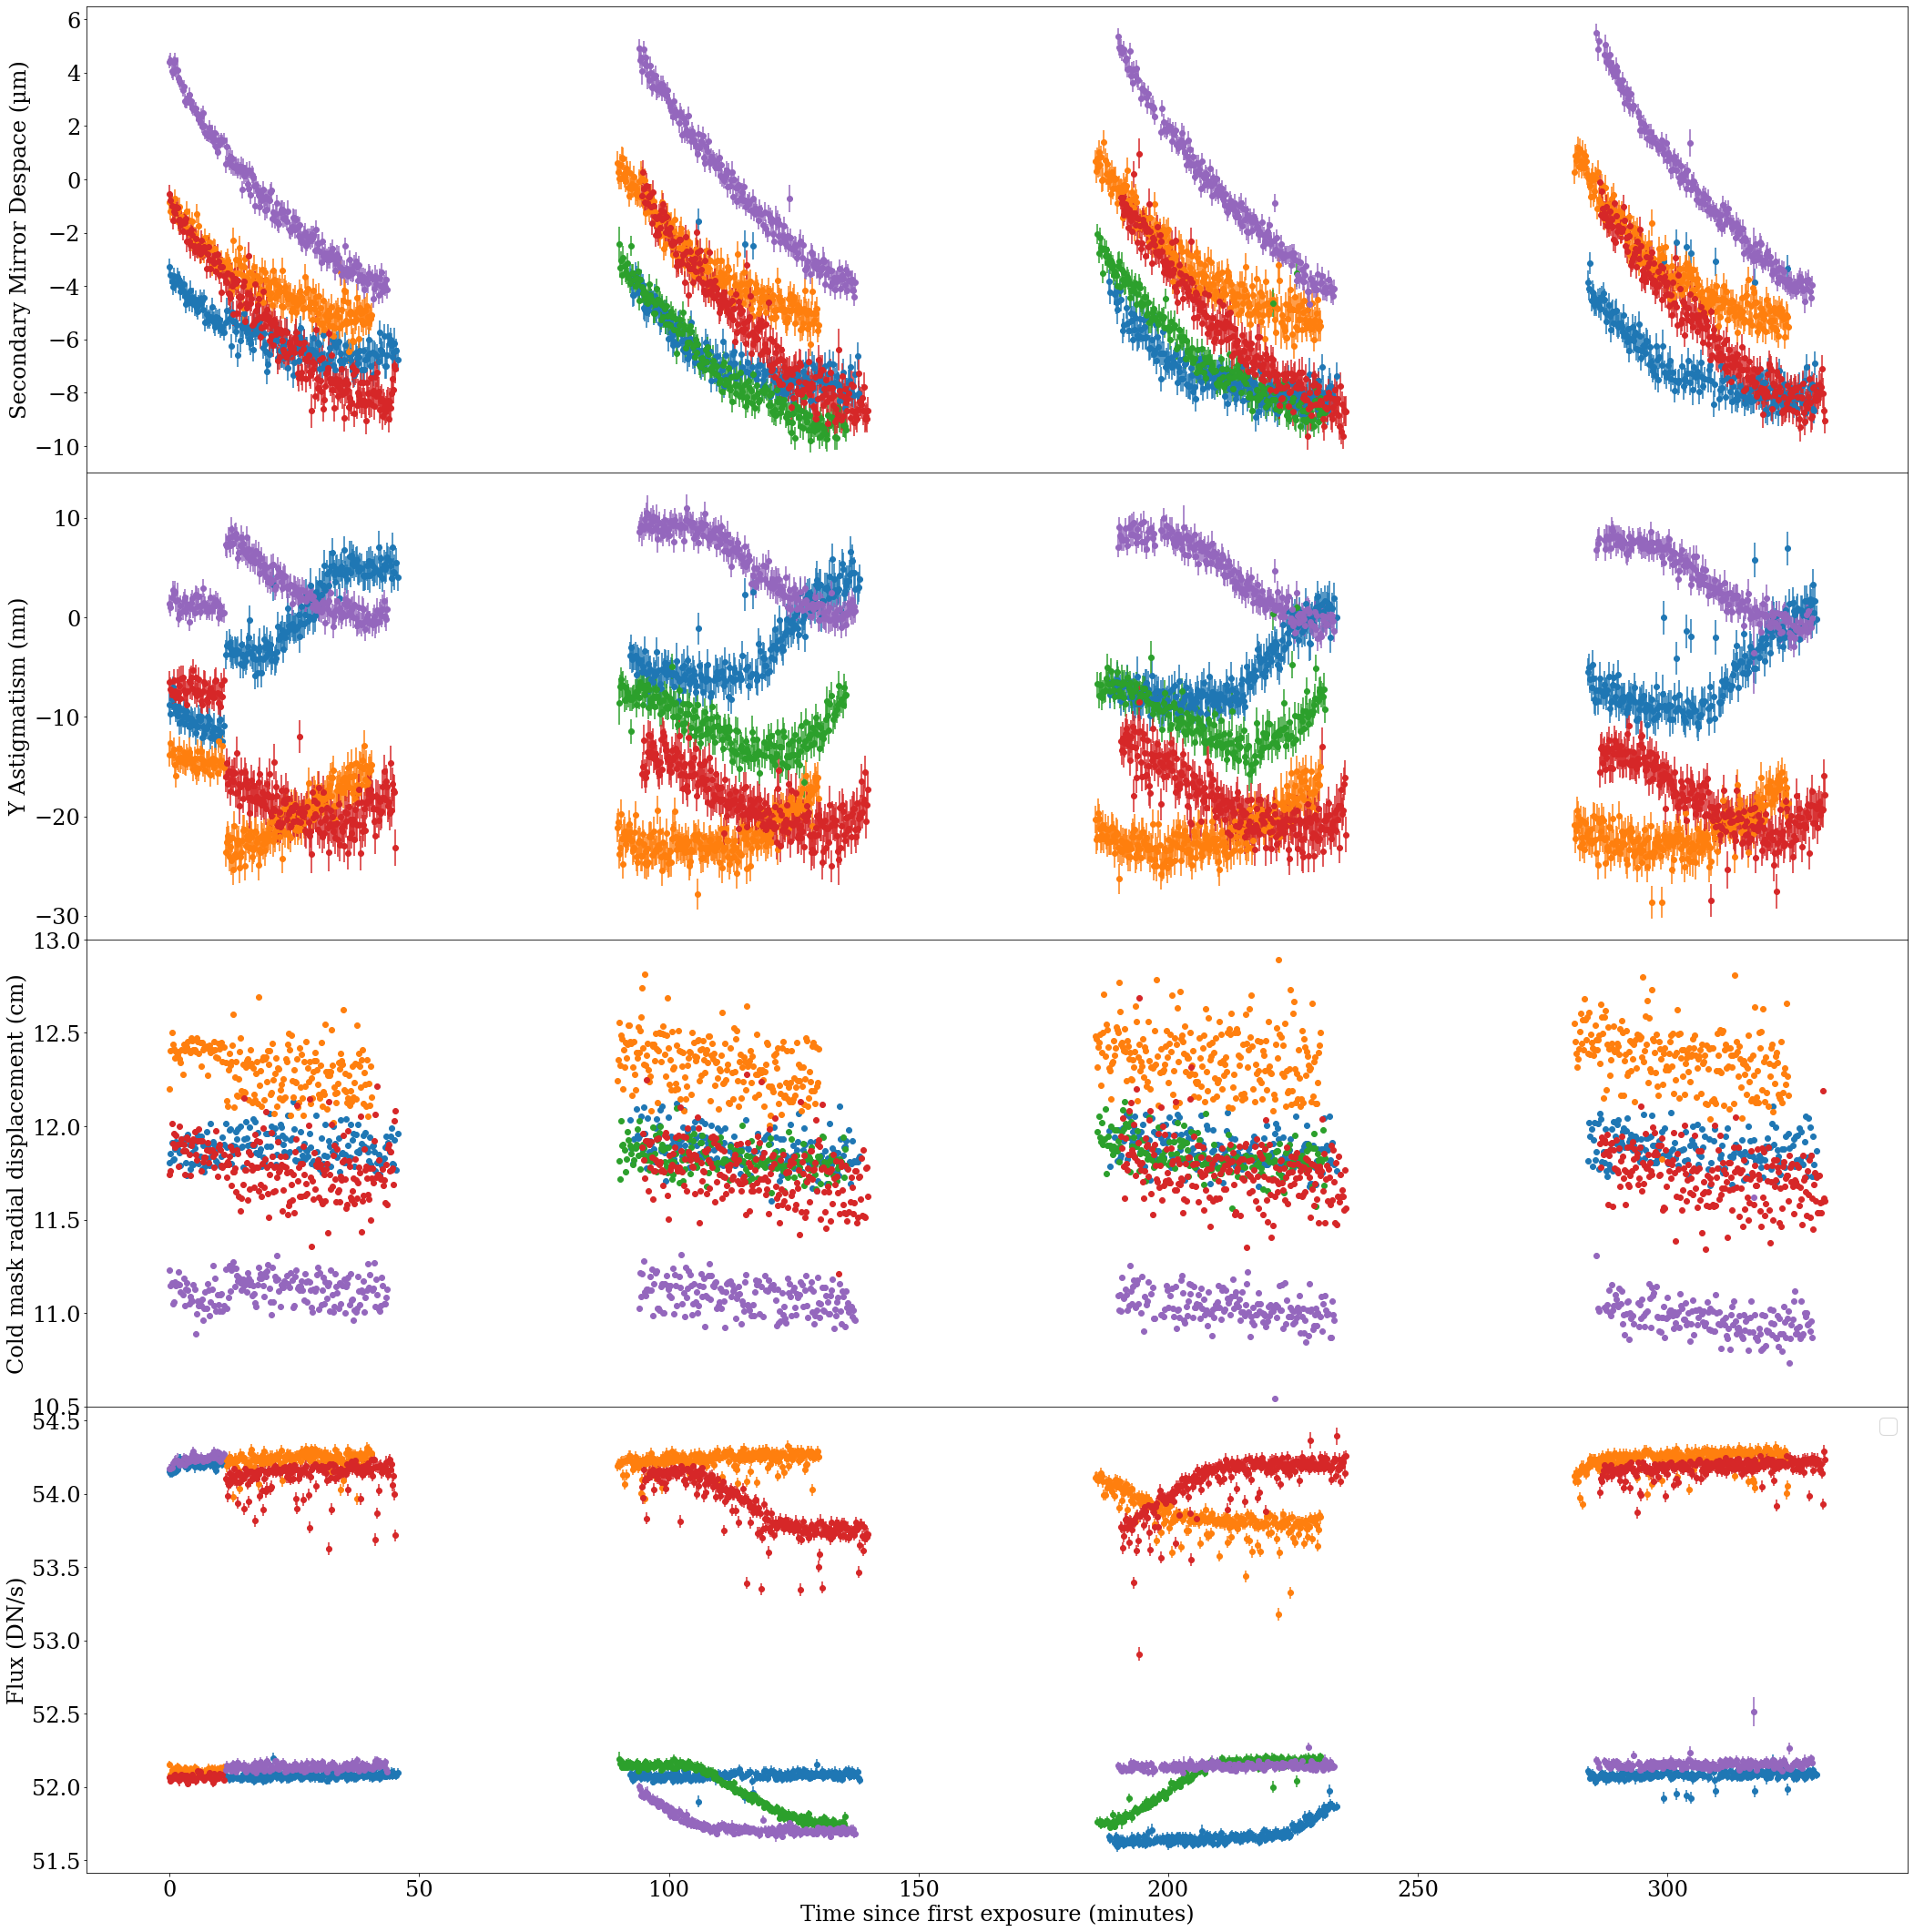

In [53]:
fig, axs = plt.subplots(nrows=4, ncols=1, sharex=True, figsize=(30,30))

idxs = [0, 4, 8, 10, 14, 18]

for i in range(5):
    valid = (clumps >= idxs[i]) & (clumps < idxs[i+1])

    fudge = 90 if i == 2 else 0

    axs[0].errorbar((mjds[valid]-np.min(mjds[valid]))*60*24 + fudge, despaces[valid], yerr=ddespaces[valid], fmt='o')

plt.legend(['15/04/2008', '03/05/2008', '18/05/2008', '28/05/2008', '11/08/2008'])

# axs[0].set_xlabel("Time since first exposure (minutes)")
axs[0].set_ylabel("Secondary Mirror Despace (µm)")

axs[0].set_ylim(-11, 6.5)

for i in range(5):
    valid = (clumps >= idxs[i]) & (clumps < idxs[i+1])

    fudge = 90 if i == 2 else 0

    axs[1].errorbar((mjds[valid]-np.min(mjds[valid]))*60*24 + fudge, zernikes[valid,index], yerr=dzernikes[valid,index], fmt='o')

axs[1].set_ylabel("Y Astigmatism (nm)")

for i in range(5):
    valid = (clumps >= idxs[i]) & (clumps < idxs[i+1])

    fudge = 90 if i == 2 else 0

    axs[2].scatter((mjds[valid]-np.min(mjds[valid]))*60*24 + fudge, np.sqrt(np.sum(coldmasks[valid]**2, axis=1)))#, format='o')

axs[2].set_ylim(10.5, 13)
axs[2].set_ylabel("Cold mask radial displacement (cm)")

for i in range(5):
    valid = (clumps >= idxs[i]) & (clumps < idxs[i+1])

    fudge = 90 if i == 2 else 0

    axs[3].errorbar((mjds[valid]-np.min(mjds[valid]))*60*24 + fudge, fluxes[valid], yerr=dfluxes[valid], fmt='o')

axs[3].set_xlabel("Time since first exposure (minutes)")
axs[3].set_ylabel("Flux (DN/s)")
fig.tight_layout()
fig.subplots_adjust(hspace=0)

fig.savefig("breathing1.pdf")

In [113]:
14, 18
valid = clumps>=-1#(clumps >= 15) & (clumps < 18)

In [114]:
pca = PCA(n_components=10)
#pca.fit(np.hstack([st_defocus[:, np.newaxis], despaces[order,np.newaxis], zernikes[order]]))
pca.fit(np.hstack([despaces[valid,np.newaxis]*6.1, zernikes[valid]]))

print(pca.singular_values_)
print(pca.components_)
print(pca.explained_variance_ratio_)
components = pca.components_

[1220.3694635   667.18027934  314.81577341  258.09696668  185.46939428
  127.52792808  105.4088186    93.7028764    76.1890086    61.07108007]
[[ 0.943128    0.03520614  0.22699942 -0.00304275 -0.06910733 -0.05031102
   0.05354336  0.10183686 -0.00796769 -0.10916463 -0.01311006  0.12558677
   0.06229122 -0.05491643 -0.01104351 -0.03386487  0.00662779  0.01477684
  -0.00845417 -0.00245097  0.02754232]
 [-0.20391666 -0.04823037  0.84038285  0.09978752  0.26977856  0.23328984
   0.02895325 -0.08998602 -0.05835736 -0.12405423  0.06470242  0.16498564
   0.09232911  0.00390124  0.01482976 -0.07630626  0.18577739 -0.03731782
   0.0319941   0.03952983 -0.02177877]
 [ 0.19439335  0.42041414 -0.08264894  0.33916314  0.43990848  0.23733057
  -0.14848088 -0.26408642 -0.00112036  0.36380455  0.04361769 -0.23137238
  -0.22443222  0.21449777  0.09360187  0.08094287  0.02012796 -0.03325239
  -0.08604907  0.07391346 -0.09003251]
 [-0.02594087  0.37183763 -0.1468853  -0.27145046  0.52934608 -0.02143349


Text(0.5, 1.0, 'Breathing Mode Principal Component')

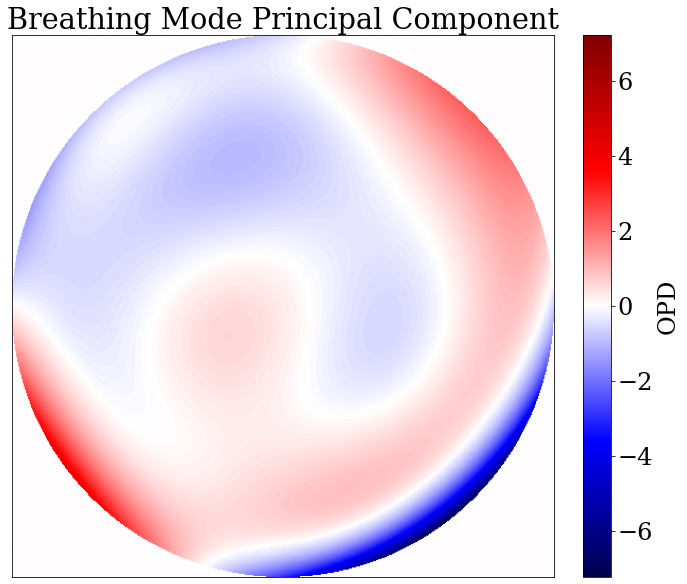

In [120]:
ap = dl.AberratedAperture(dl.CircularAperture(radius=1.2), noll_inds=np.arange(4,4+21), coefficients=components[1])
coords = dlu.pixel_coords(512, 2.4)

opd = ap.eval_basis(coords)#*1e9
m = np.max(np.abs(opd))
plt.figure(figsize=(10,8), layout="constrained")
plt.imshow(opd, cmap='seismic', vmin=-m, vmax=m)
plt.xticks([])
plt.yticks([])
plt.colorbar(label="OPD")
plt.title("Breathing Mode Principal Component")

In [211]:
len(components[0])

21

In [212]:
len(["Despace"] + [dlu.zernike_name(i+5) for i in range(20)])

21

In [245]:
data

{'PC 1': [np.float64(0.9779065978450397),
  Array(0.17960303, dtype=float64),
  Array(0.07234163, dtype=float64),
  Array(0.05349152, dtype=float64)],
 'PC 2': [np.float64(-0.06376168180190693),
  Array(0.6250415, dtype=float64),
  Array(0.37083962, dtype=float64),
  Array(0.18407751, dtype=float64)],
 'PC 3': [np.float64(-0.017028588144271335),
  Array(0.77154274, dtype=float64),
  Array(0.37588223, dtype=float64),
  Array(0.17732557, dtype=float64)]}

(array([0, 1, 2, 3]),
 [Text(0, 0, 'Despace'),
  Text(1, 0, 'Astigmatism'),
  Text(2, 0, 'Coma'),
  Text(3, 0, 'Trefoil')])

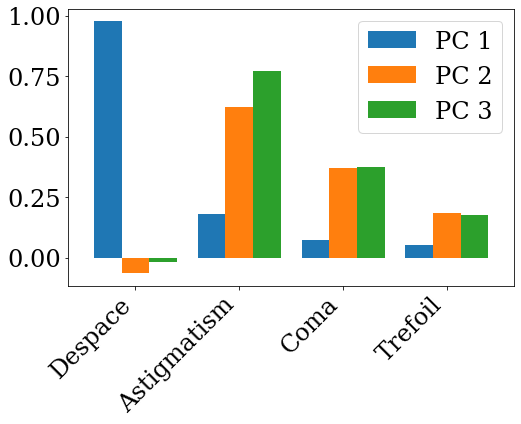

In [246]:
names = ["Despace", "Astigmatism", "Coma", "Trefoil"] #+ [dlu.zernike_name(i+5) for i in range(7)]
data = {
    f"PC {i+1}": np.array([components[i,0], np.sqrt(np.sum(components[i, 1:3]**2)), np.sqrt(np.sum(components[i, 3:5]**2)), np.sqrt(np.sum(components[i, 5:7]**2))]) for i in range(3)
}
df = pd.DataFrame(data, index=names)
df.plot(kind='bar', figsize=(8, 5), width=0.8)
plt.xticks(rotation=45, ha='right')

In [228]:
data

{'Despace': array([ 0.97309048,  0.00171983, -0.09766694]),
 'Astig X': array([-0.08172558,  0.64717982,  0.02878593]),
 'Astig Y': array([0.19722079, 0.22849311, 0.52104067]),
 'Coma X': array([0.02928922, 0.37573679, 0.00852283]),
 'Coma Y': array([-0.04815445, -0.10369979,  0.39087369]),
 'Trefoil X': array([-0.03357458,  0.04569826, -0.05662634]),
 'Trefoil Y': array([-0.01704882,  0.17209551,  0.05280533]),
 'Spherical': array([ 0.01571565, -0.101221  ,  0.33714806])}

([0, 1, 2, 3, 4, 5, 6, 7],
 [Text(0, 0, 'Despace'),
  Text(1, 0, 'Astig X'),
  Text(2, 0, 'Astig Y'),
  Text(3, 0, 'Coma X'),
  Text(4, 0, 'Coma Y'),
  Text(5, 0, 'Trefoil X'),
  Text(6, 0, 'Trefoil Y'),
  Text(7, 0, 'Spherical')])

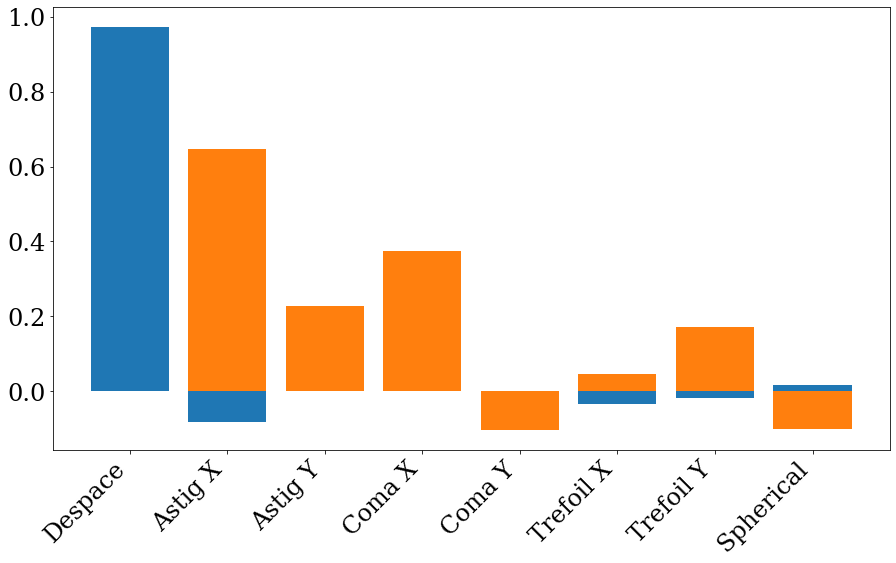

In [226]:
plt.figure(figsize=(15,8))
plt.bar(["Despace"] + [dlu.zernike_name(i+5) for i in range(7)], components[0,:8])
plt.bar(["Despace"] + [dlu.zernike_name(i+5) for i in range(7)], components[1,:8])

plt.xticks(rotation=45, ha='right')

In [204]:
dlu.zernike_name(4)

'Defocus'

In [186]:
support_mask = np.load("aperture_support.npy")
cmap = matplotlib.colormaps['seismic']
cmap.set_bad('k',1)

[0.55472568 0.19291119 0.0923664  0.06248574 0.03762246 0.0196763
 0.01032839 0.00818367]
[0.77951127 0.08673879 0.04778006 0.03619301 0.01381929 0.01003767
 0.00823649 0.0034649 ]
[0.84476605 0.05745015 0.03728573 0.02514911 0.01088719 0.00769224
 0.00607333 0.00295768]
[0.83394613 0.07018953 0.0337608  0.02322862 0.01059492 0.00961288
 0.00622432 0.00260837]
[0.91678723 0.03285675 0.02085512 0.0090167  0.00656157 0.00344868
 0.00299108 0.00183849]


/var/folders/hv/659ls99s2sjd7m3dfr17k8cm0000gn/T/ipykernel_3591/2745090468.py:67: UserWarning: This figure was using a layout engine that is incompatible with subplots_adjust and/or tight_layout; not calling subplots_adjust.
  fig.subplots_adjust(wspace=0, hspace=0)


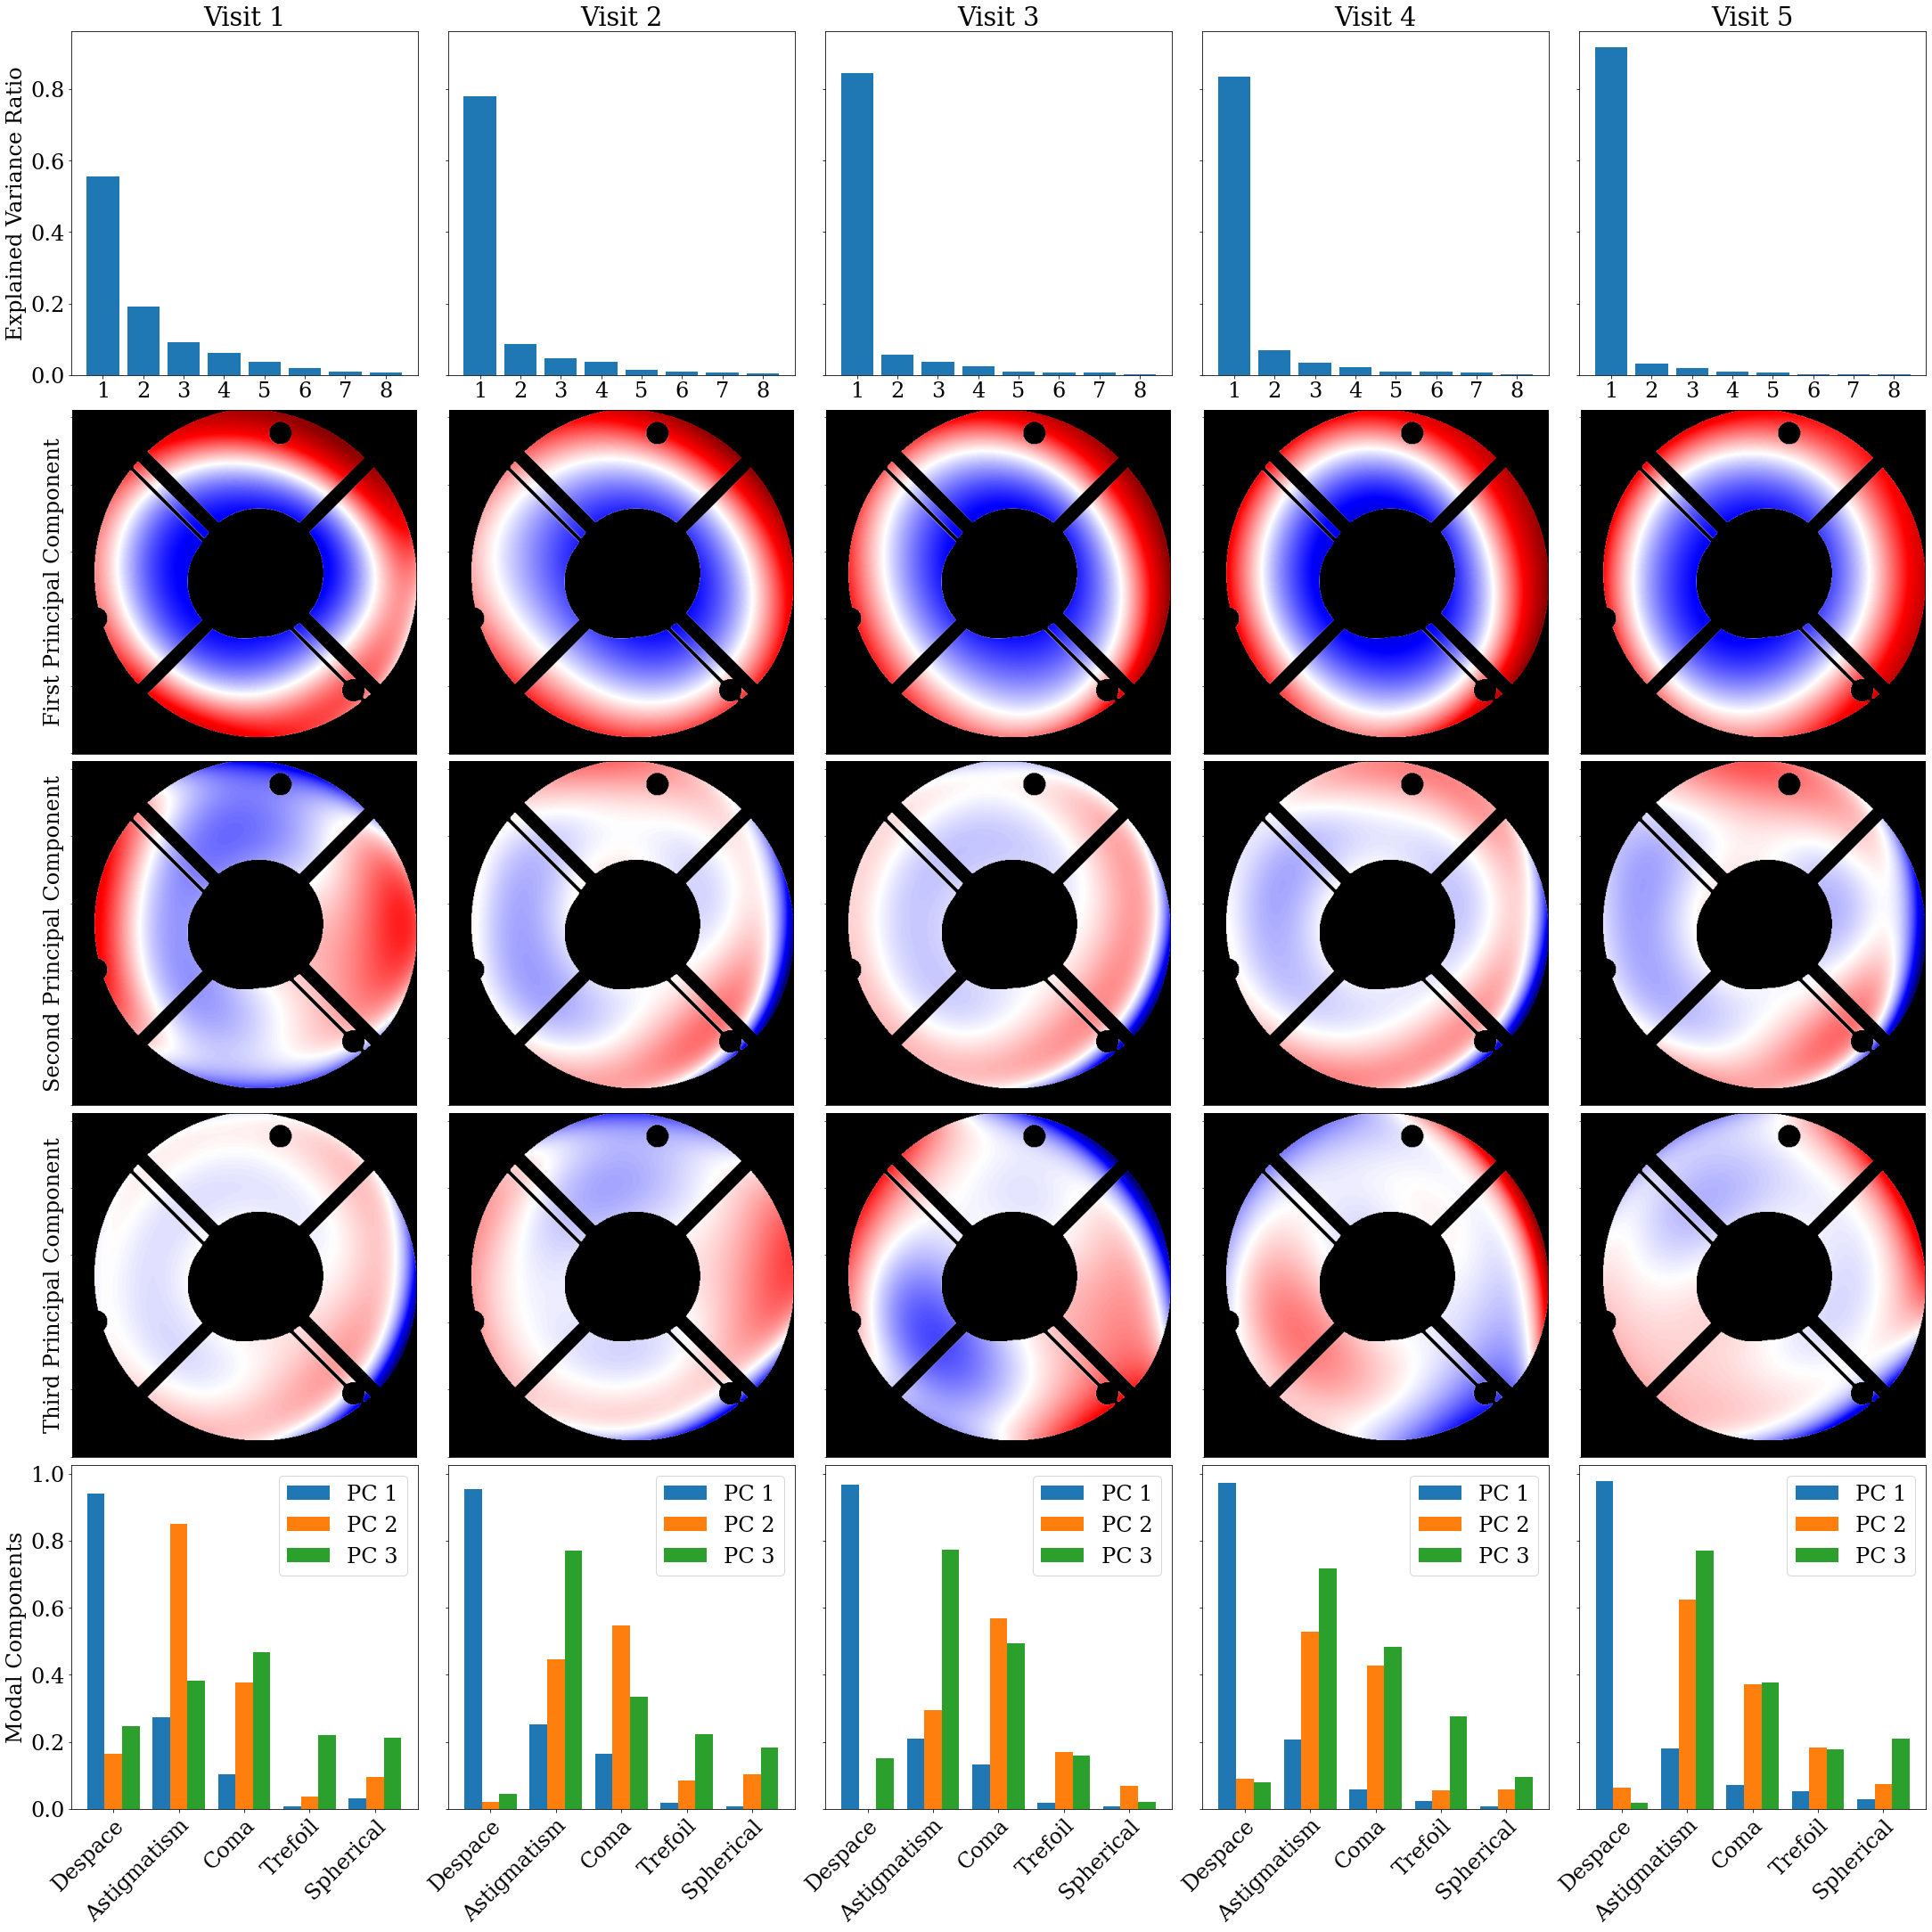

In [264]:
idxs = [0, 4, 8, 10, 14, 18]

fig, axs = plt.subplots(5, 5, figsize=(6*5,6*5), layout='constrained', sharey='row')

angles = [
    0.,
    90.,
    82.985588,
    71.344803,
    60.98637,
    56.314529,
    329.616394,
]

for i in range(5):
    valid = (clumps >= idxs[i]) & (clumps < idxs[i+1])

    pca = PCA(n_components=8)
    #pca.fit(np.hstack([st_defocus[:, np.newaxis], despaces[order,np.newaxis], zernikes[order]]))
    pca.fit(np.hstack([despaces[valid,np.newaxis]*6.1, zernikes[valid]]))

    # print(pca.singular_values_)
    # print(pca.components_)
    print(pca.explained_variance_ratio_)

    axs[0,i].bar(np.arange(len(pca.explained_variance_))+1, pca.explained_variance_ratio_)
    axs[0,i].set_title(f"Visit {i+1}")
    axs[0,i].set_xticks(np.arange(8)+1)


    for j in range(3):

        components = pca.components_
        sign = -1 if j==2 and i==0 else 1

        ap = dl.AberratedAperture(dl.CircularAperture(radius=1.2), noll_inds=np.arange(4,4+21), coefficients=components[j]*sign*np.sign(np.sum(np.sign(components[j,:3]))))
        coords = dlu.pixel_coords(512, 2.4)

        opd = ap.eval_basis(coords)#*1e9
        m = np.max(np.abs(opd))
        
        axs[j+1, i].imshow(opd*support_mask, cmap=cmap, vmin=-m, vmax=m)
        axs[j+1, i].set_xticks([])
        axs[j+1, i].set_yticks([])

    names = ["Despace", "Astigmatism", "Coma", "Trefoil", "Spherical"] #+ [dlu.zernike_name(i+5) for i in range(7)]
    data = {
        f"PC {i+1}": np.array([np.abs(components[i,0]), np.sqrt(np.sum(components[i, 1:3]**2)), np.sqrt(np.sum(components[i, 3:5]**2)), np.sqrt(np.sum(components[i, 5:7]**2)), np.abs(components[i,8])]) for i in range(3)
    }

    df = pd.DataFrame(data, index=names)
    df.plot(kind='bar', ax=axs[4,i], width=0.8)
    axs[4,i].set_xticklabels(axs[4,i].get_xticklabels(), rotation=45, ha='right', rotation_mode='anchor')

        # axs[i, j+1].axline((256,256), (257, 256 + np.tan(dlu.deg2rad(angles[i]+65))))
    # plt.colorbar(label="OPD")
    # plt.title("Breathing Mode Principal Component")

axs[0,0].set_ylabel("Explained Variance Ratio")
axs[1,0].set_ylabel("First Principal Component")
axs[2,0].set_ylabel("Second Principal Component")
axs[3,0].set_ylabel("Third Principal Component")
axs[4,0].set_ylabel("Modal Components")


# plt.subplots_adjust(hspace=0)
fig.subplots_adjust(wspace=0, hspace=0)
# fig.tight_layout()
plt.savefig("pca_modes.pdf")

[0.55472568 0.19291119 0.0923664  0.06248574 0.03762246 0.0196763
 0.01032839 0.00818367]
[0.77951127 0.08673879 0.04778006 0.03619301 0.01381929 0.01003767
 0.00823649 0.0034649 ]
[0.84476605 0.05745015 0.03728573 0.02514911 0.01088719 0.00769224
 0.00607333 0.00295768]
[0.83394613 0.07018953 0.0337608  0.02322862 0.01059492 0.00961288
 0.00622432 0.00260837]
[0.91678723 0.03285675 0.02085512 0.0090167  0.00656157 0.00344868
 0.00299108 0.00183849]


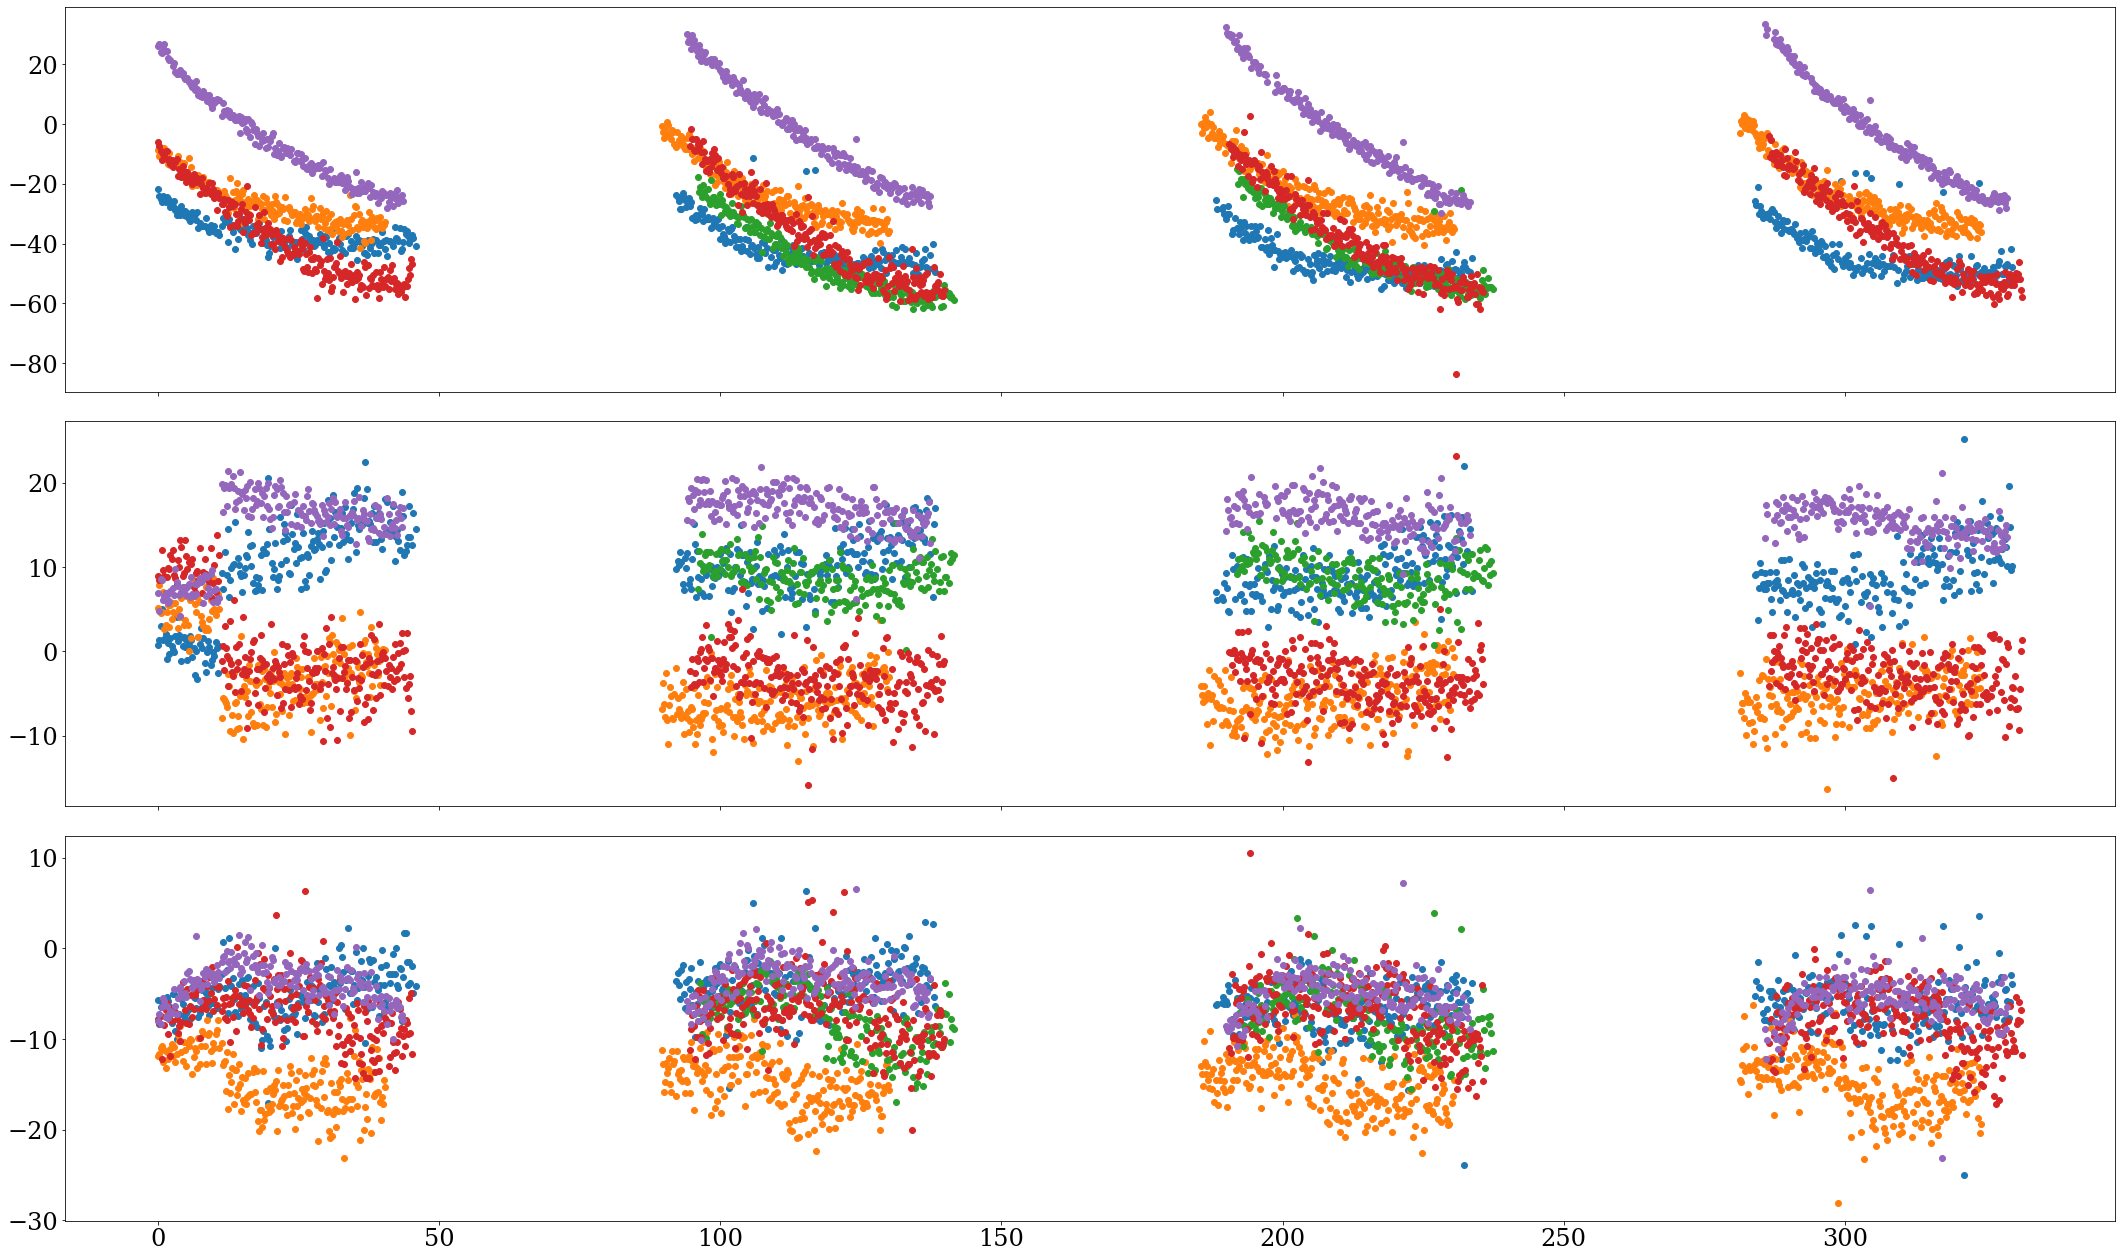

In [ ]:
idxs = [0, 4, 8, 10, 14, 18]

fig, axs = plt.subplots(nrows=3, ncols=1, figsize=(6*5,6*3), sharex=True)


for i in range(5):
    valid = (clumps >= idxs[i]) & (clumps < idxs[i+1])

    pca = PCA(n_components=8)
    #pca.fit(np.hstack([st_defocus[:, np.newaxis], despaces[order,np.newaxis], zernikes[order]]))
    data = np.hstack([despaces[valid,np.newaxis]*6.1, zernikes[valid]])
    pca.fit(data)

    # print(pca.singular_values_)
    # print(pca.components_)
    print(pca.explained_variance_ratio_)

    fudge = 96 if i == 2 else 0

    axs[0].scatter((mjds[valid]-np.min(mjds[valid]))*60*24 + fudge, np.dot(components[0], data.T))#, fmt='o')
    axs[1].scatter((mjds[valid]-np.min(mjds[valid]))*60*24 + fudge, np.dot(components[1], data.T))#, fmt='o')
    axs[2].scatter((mjds[valid]-np.min(mjds[valid]))*60*24 + fudge, np.dot(components[2], data.T))#, fmt='o')



# axs[0,0].set_ylabel("Explained Variance Ratio")
# axs[1,0].set_ylabel("First Principal Component")
# axs[2,0].set_ylabel("Second Principal Component")
# axs[3,0].set_ylabel("Third Principal Component")
# axs[4,0].set_ylabel("Modal Components")

axs[2].set_xlabel("Time since first exposure (minutes)")


# # plt.subplots_adjust(hspace=0)
# fig.subplots_adjust(wspace=0, hspace=0)
fig.tight_layout()
# plt.savefig("pca_modes.pdf")

(-11.0, 6.5)

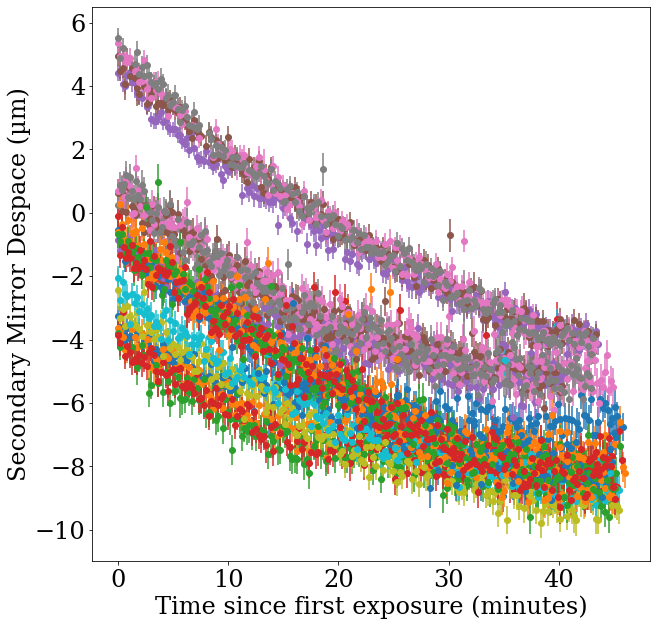

In [91]:
plt.figure(figsize=(10,10))
for i in range(18):
    valid = clumps==i

    plt.errorbar((mjds[valid]-np.min(mjds[valid]))*60*24, despaces[valid], yerr=ddespaces[valid], fmt='o')

plt.xlabel("Time since first exposure (minutes)")
plt.ylabel("Secondary Mirror Despace (µm)")
plt.ylim(-11, 6.5)

Text(0, 0.5, 'Astig Y (nm)')

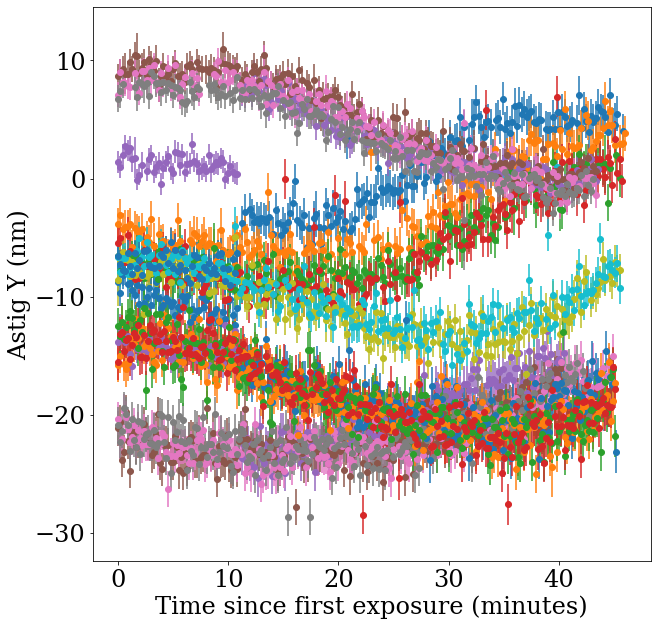

In [92]:
index = 1
plt.figure(figsize=(10,10))
for i in range(18):
    valid = clumps==i

    plt.errorbar((mjds[valid]-np.min(mjds[valid]))*60*24, zernikes[valid,index], yerr=dzernikes[valid,index], fmt='o')

plt.xlabel("Time since first exposure (minutes)")
plt.ylabel("Astig Y (nm)")


In [93]:
stop

NameError: name 'stop' is not defined

In [ ]:
import pandas as pd
model = pd.read_csv("../data/breathing-11-08-2008.txt", sep=",")[1:]

In [ ]:
model.keys()

Index(['Julian Date', 'Date', 'Time', 'Model'], dtype='object')

In [ ]:
print(res.keys())

KeysView(NpzFile '../batch/breathing-data/params/na2m53fyq.npz' with keys: mjd, params, uncertainty, fisher)


In [ ]:
order = mjds.argsort()[-570:]#[-769:]#[-1600:-769]

In [ ]:
np.unique(np.round(mjds))

Array([54572., 54589., 54590., 54605., 54612., 54689., 54690.], dtype=float64)

In [ ]:
min_jd = mjds[order][0]
max_jd = mjds[order][-1]

model_order = (model['Julian Date']> min_jd) & (model['Julian Date'] < max_jd)

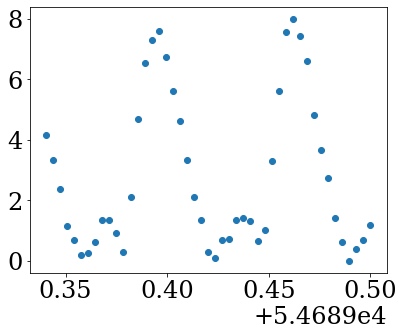

In [ ]:
plt.scatter(model['Julian Date'][model_order], model['Model'][model_order])

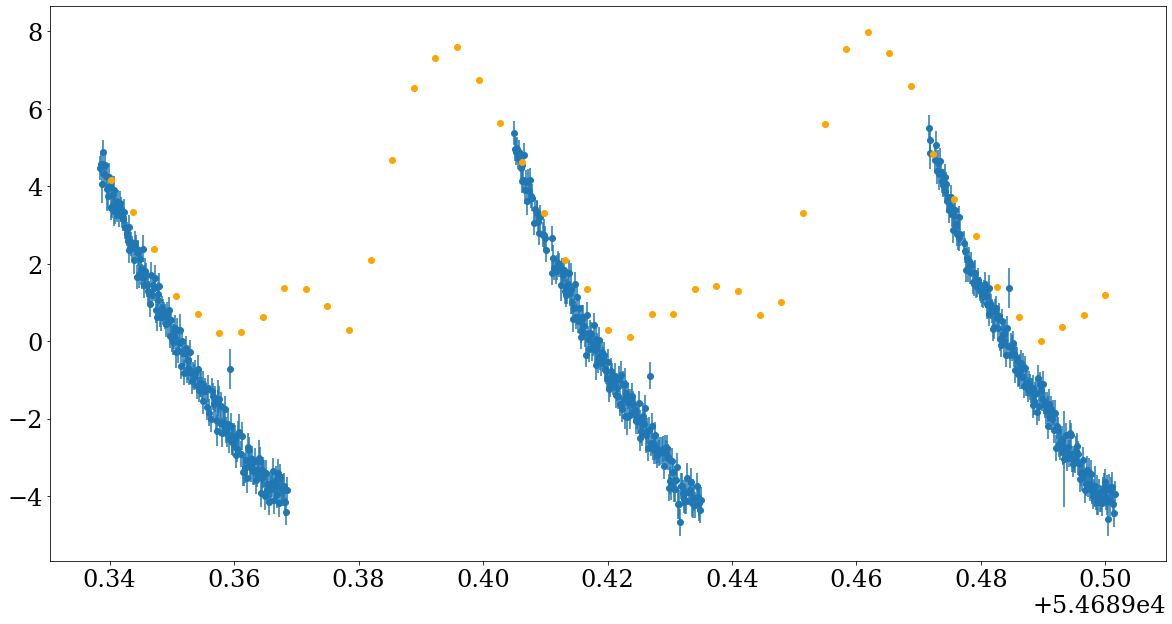

In [ ]:
plt.figure(figsize=(20,10))


plt.errorbar(mjds[order], despaces[order], yerr=ddespaces[order], fmt = 'o')
#plt.ylim(ymin1, ymin1+yrange)
#plt.twinx()
plt.scatter(model['Julian Date'][model_order], model['Model'][model_order], color="orange", zorder=5)
#plt.ylim(ymin2, ymin2+yrange)


In [ ]:
from scipy.optimize import curve_fit

In [ ]:
st_defocus = ipx.interp1d(mjds[order], model['Julian Date'][model_order].to_numpy(), model['Model'][model_order].to_numpy(), extrap=True)

In [ ]:
mode_predictors = np.hstack([despaces[order,np.newaxis], zernikes[order]]).T

In [ ]:
pca = PCA(n_components=5)
#pca.fit(np.hstack([st_defocus[:, np.newaxis], despaces[order,np.newaxis], zernikes[order]]))
pca.fit(mode_predictors.T)

print(pca.singular_values_)
print(pca.components_)
print(pca.explained_variance_ratio_)
components = pca.components_

[112.27816451  60.53930826  50.47317083  33.42263553  23.3878764 ]
[[ 5.39124086e-01 -2.83819205e-01  7.29989096e-01  1.03642983e-01
  -1.29798551e-01 -1.27220290e-01 -5.36922767e-02  7.80359711e-02
   1.36432359e-01 -1.05141889e-01 -2.02593831e-02  2.55907880e-02
   2.59683260e-02  8.78585843e-03  9.23005071e-03 -5.57951546e-02
   1.78023802e-02  2.16118173e-02 -2.15965619e-02 -6.47169526e-02
   5.51210040e-02]
 [ 2.88351075e-03  6.45659675e-01  2.35184829e-01  3.76382757e-01
  -1.02240696e-01  4.46906543e-02  1.72162759e-01 -9.88604979e-02
   1.55447760e-01  3.13959500e-01  3.25021053e-04 -4.17342796e-02
  -1.40218488e-01  2.01812170e-01  1.31822489e-01 -1.60140836e-03
   1.07778442e-02 -4.14004808e-02 -2.85151341e-01  2.16806874e-01
   4.33975678e-02]
 [-2.39874801e-01  1.63042610e-01  2.38570390e-01 -4.70531324e-02
   4.88740386e-01  8.85082969e-03  7.86628337e-02  3.52417760e-01
   2.98040903e-01 -6.06508702e-02  7.49423092e-02 -8.96539744e-02
   5.68162951e-01 -4.40977757e-02  6.

In [ ]:
def breathing_model(x, *vals):
    vls = np.array(vals)[:45]
    components = np.array(vals)[45:].reshape((3,21))
    return (np.polyval(vls[:15], np.sum(x*components[0], axis=1))
            + np.polyval(vls[15:30], np.sum(x*components[1], axis=1))
            + 0.*np.polyval(vls[30:], np.sum(x*components[2], axis=1)))

In [ ]:
pstart = np.array([ 1.03006680e-15, -3.45507554e-14,  5.14278202e-13, -3.00657628e-11,
        6.43344997e-10,  2.00093690e-09,  3.81547967e-08, -4.57775317e-06,
       -2.85972656e-06,  1.06525039e-03,  6.51365970e-03, -3.74820064e-01,
        3.71372229e+00, -1.55316644e+01,  2.64364911e+01,  0.00000000e+00,
        0.00000000e+00,  0.00000000e+00,  0.00000000e+00,  0.00000000e+00,
        0.00000000e+00,  0.00000000e+00,  0.00000000e+00,  0.00000000e+00,
        0.00000000e+00,  0.00000000e+00,  0.00000000e+00,  0.00000000e+00,
        0.00000000e+00,  0.00000000e+00,  0.00000000e+00,  0.00000000e+00,
        0.00000000e+00,  0.00000000e+00,  0.00000000e+00,  0.00000000e+00,
        0.00000000e+00,  0.00000000e+00,  0.00000000e+00,  0.00000000e+00,
        0.00000000e+00,  0.00000000e+00,  0.00000000e+00,  0.00000000e+00,
        0.00000000e+00,  1.55989403e+00,  1.87958573e-01, -1.44218494e-01,
       -1.19642931e-01, -5.97943746e-02,  1.96989165e-01, -1.41696108e-02,
        1.20784999e-02,  2.07148121e-01, -1.37953586e-01, -1.46772599e-01,
       -1.28708739e-01,  2.25820581e-01, -9.76335162e-02, -3.93618495e-02,
       -1.07919821e-01,  2.03911346e-02,  5.67662202e-02,  1.68538429e-01,
        2.44672985e-04,  4.05316344e-02,  2.88351075e-03,  6.45659675e-01,
        2.35184829e-01,  3.76382757e-01, -1.02240696e-01,  4.46906543e-02,
        1.72162759e-01, -9.88604979e-02,  1.55447760e-01,  3.13959500e-01,
        3.25021053e-04, -4.17342796e-02, -1.40218488e-01,  2.01812170e-01,
        1.31822489e-01, -1.60140836e-03,  1.07778442e-02, -4.14004808e-02,
       -2.85151341e-01,  2.16806874e-01,  4.33975678e-02, -2.39874801e-01,
        1.63042610e-01,  2.38570390e-01, -4.70531324e-02,  4.88740386e-01,
        8.85082969e-03,  7.86628337e-02,  3.52417760e-01,  2.98040903e-01,
       -6.06508702e-02,  7.49423092e-02, -8.96539744e-02,  5.68162951e-01,
       -4.40977757e-02,  6.02141916e-02,  3.14944403e-02, -4.52158313e-02,
        2.73207777e-02,  1.75268093e-01,  1.22814256e-01,  5.73594107e-02])

pdefault = np.concat((np.zeros(45), components[0], components[1], components[2]))

In [ ]:
popt, pcov = curve_fit(breathing_model, mode_predictors.T, st_defocus, pstart, maxfev=100000)#np.ones((1,20+4*21)))

/var/folders/hv/659ls99s2sjd7m3dfr17k8cm0000gn/T/ipykernel_4442/963577263.py:1: OptimizeWarning: Covariance of the parameters could not be estimated
  popt, pcov = curve_fit(breathing_model, mode_predictors.T, st_defocus, pstart, maxfev=100000)#np.ones((1,20+4*21)))


In [ ]:
popt

array([ 9.56059452e-16, -2.11257492e-14,  3.68391171e-13, -3.60140302e-11,
        6.13797697e-10,  3.74879446e-09,  7.83349301e-08, -4.53219809e-06,
       -1.60943762e-05,  8.76760596e-04,  9.33728798e-03, -3.11278357e-01,
        2.55660185e+00, -9.21534209e+00,  2.03488442e+01, -5.80857176e-19,
        3.87064213e-17,  1.76891910e-17, -4.06344727e-14,  1.15039293e-12,
       -7.64413735e-11,  3.19248402e-09, -2.87230626e-08, -8.71086049e-07,
        1.56372741e-05,  2.32016778e-05, -1.36639417e-03,  3.32013027e-03,
        9.43981156e-03, -6.07070767e+00,  0.00000000e+00,  0.00000000e+00,
        0.00000000e+00,  0.00000000e+00,  0.00000000e+00,  0.00000000e+00,
        0.00000000e+00,  0.00000000e+00,  0.00000000e+00,  0.00000000e+00,
        0.00000000e+00,  0.00000000e+00,  0.00000000e+00,  0.00000000e+00,
        0.00000000e+00,  1.74552232e+00,  1.28550743e-01, -2.45830071e-01,
       -8.35746887e-02, -6.54111161e-02,  1.10518830e-01,  7.67044535e-02,
        4.84005260e-02,  

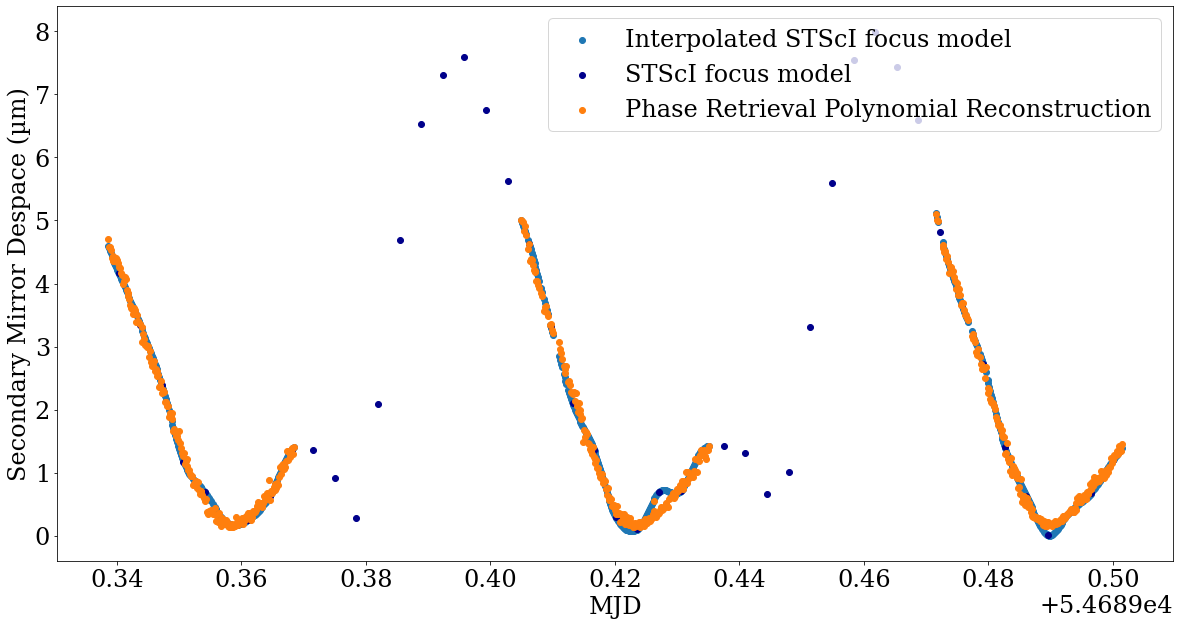

In [ ]:
plt.figure(figsize=(20,10))

plt.scatter(mjds[order], st_defocus, label="Interpolated STScI focus model")
plt.scatter(model['Julian Date'][model_order], model['Model'][model_order], color="darkblue", label="STScI focus model")

#plt.errorbar(model['Julian Date'][model_order], model['Model'][model_order], color="orange", yerr=1.6, fmt='o')
plt.scatter(mjds[order], breathing_model(mode_predictors.T, *popt), label="Phase Retrieval Polynomial Reconstruction")



plt.xlabel("MJD")
plt.ylabel("Secondary Mirror Despace (µm)")
plt.legend()

In [ ]:
stop

NameError: name 'stop' is not defined

In [ ]:
pca = PCA(n_components=5)
#pca.fit(np.hstack([st_defocus[:, np.newaxis], despaces[order,np.newaxis], zernikes[order]]))
pca.fit(np.hstack([despaces[order,np.newaxis], zernikes[order]]))

print(pca.singular_values_)
print(pca.components_)
print(pca.explained_variance_ratio_)
components = pca.components_

[112.27816451  60.53930826  50.47317083  33.42263553  23.3878764 ]
[[ 5.39124086e-01 -2.83819205e-01  7.29989096e-01  1.03642983e-01
  -1.29798551e-01 -1.27220290e-01 -5.36922767e-02  7.80359711e-02
   1.36432359e-01 -1.05141889e-01 -2.02593831e-02  2.55907880e-02
   2.59683260e-02  8.78585843e-03  9.23005071e-03 -5.57951546e-02
   1.78023802e-02  2.16118173e-02 -2.15965619e-02 -6.47169526e-02
   5.51210040e-02]
 [ 2.88351075e-03  6.45659675e-01  2.35184829e-01  3.76382757e-01
  -1.02240696e-01  4.46906543e-02  1.72162759e-01 -9.88604979e-02
   1.55447760e-01  3.13959500e-01  3.25021053e-04 -4.17342796e-02
  -1.40218488e-01  2.01812170e-01  1.31822489e-01 -1.60140836e-03
   1.07778442e-02 -4.14004808e-02 -2.85151341e-01  2.16806874e-01
   4.33975678e-02]
 [-2.39874801e-01  1.63042610e-01  2.38570390e-01 -4.70531324e-02
   4.88740386e-01  8.85082969e-03  7.86628337e-02  3.52417760e-01
   2.98040903e-01 -6.06508702e-02  7.49423092e-02 -8.96539744e-02
   5.68162951e-01 -4.40977757e-02  6.

([], [])

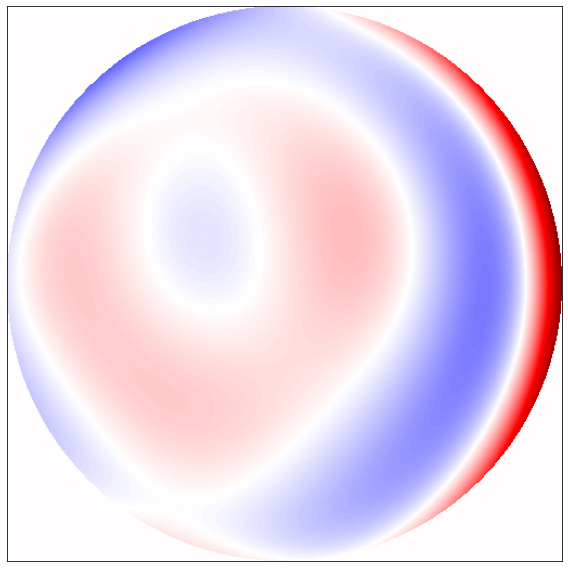

In [ ]:
ap = dl.AberratedAperture(dl.CircularAperture(radius=1.2), noll_inds=np.arange(5,5+20), coefficients=components[2][1:])
coords = dlu.pixel_coords(512, 2.4)

opd = ap.eval_basis(coords)#*1e9
m = np.max(np.abs(opd))
plt.figure(figsize=(10,10))
plt.imshow(opd, cmap='seismic', vmin=-m, vmax=m)
plt.xticks([])
plt.yticks([])

In [ ]:
from sklearn.cross_decomposition import PLSRegression

In [ ]:
mode_predictors.shape

(21, 570)

In [ ]:
pls = PLSRegression(n_components=5)
pls.fit(mode_predictors.T, st_defocus)
pls.score(mode_predictors.T, st_defocus)

0.8566062684552732

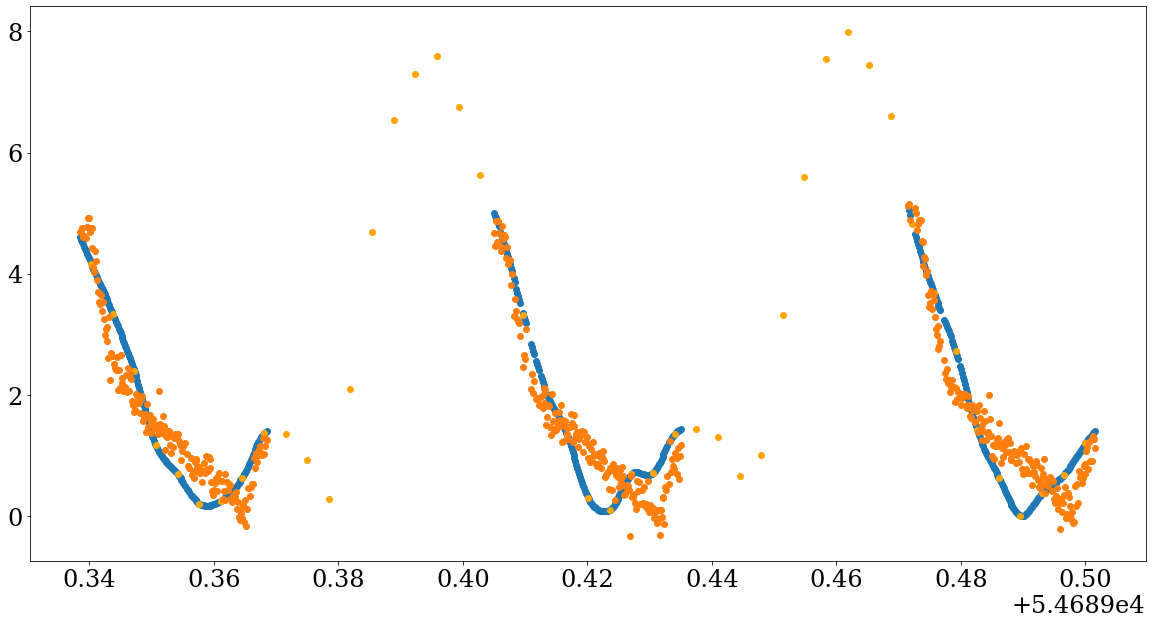

In [ ]:
plt.figure(figsize=(20,10))

plt.scatter(mjds[order], st_defocus)
plt.scatter(model['Julian Date'][model_order], model['Model'][model_order], color="orange")
plt.scatter(mjds[order], pls.predict(mode_predictors.T))

In [ ]:
comp = pca.components_

In [ ]:
print([float(x) for x in (pca.components_[0])])

[0.5391240856164041, -0.283819205279893, 0.7299890963366577, 0.10364298346165703, -0.12979855127661322, -0.12722029004352722, -0.05369227672627769, 0.0780359710517295, 0.13643235930869246, -0.10514188876885436, -0.020259383135278846, 0.025590787976876823, 0.02596832601237816, 0.008785858431448221, 0.009230050706372853, -0.05579515457596127, 0.01780238021816142, 0.02161181731308003, -0.02159656187538148, -0.06471695263573214, 0.05512100397798705]


In [ ]:
pca.explained_variance_ratio_[:3].sum()/pca.explained_variance_ratio_.sum()

np.float64(0.9187587122081812)

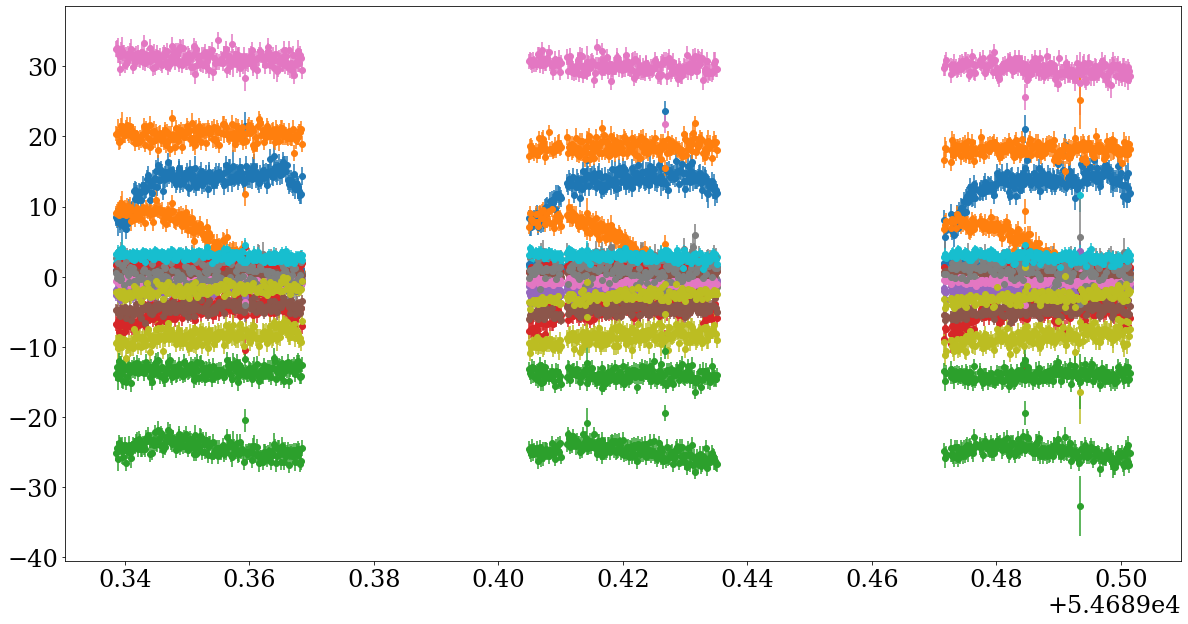

In [ ]:
plt.figure(figsize=(20,10))

yrange = np.max(despaces[order])-np.min(despaces[order])
ymin1 = np.min(despaces[order])

#ymin2 = np.min(model['Model'][model_order].to_numpy())

yoff = 0.

for i in range(20):
    plt.errorbar(mjds[order], zernikes[order,i], yerr=dzernikes[order, i], fmt = 'o')
#plt.ylim(ymin1, ymin1+yrange)
#plt.twinx()
#plt.scatter(model['Julian Date'][model_order], model['Model'][model_order], color="orange")
#plt.ylim(ymin2, ymin2+yrange)


In [ ]:
dzernikes[0]

Array([1.01965127, 0.89303122, 0.86115232, 0.8812162 , 0.6977012 ,
       0.67726474, 0.91103473, 0.81162169, 0.91848806, 0.49779087,
       0.44694654, 0.89483496, 0.84449998, 0.54744496, 0.56551418,
       0.43833058, 0.42988867, 1.11747175, 0.61593869, 0.52448207],      dtype=float64)

In [ ]:
mjds[order][0]

Array(54689.3385379, dtype=float64)

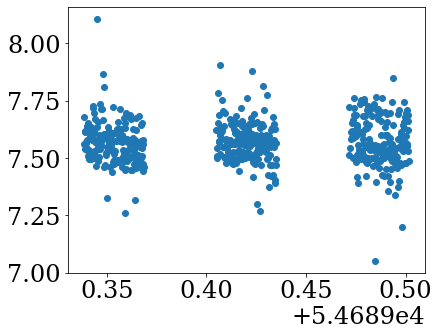

In [ ]:
plt.scatter(mjds[order], coldmasks[order,0])

<ErrorbarContainer object of 3 artists>

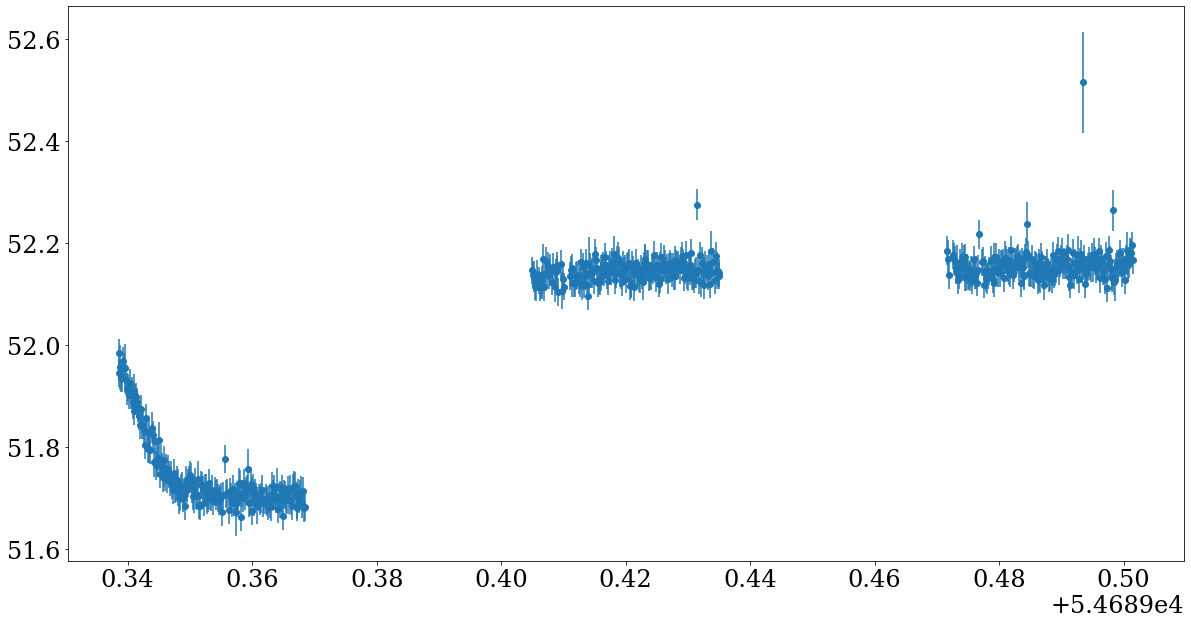

In [ ]:
plt.figure(figsize=(20, 10))
plt.errorbar(mjds[order], fluxes[order], yerr=dfluxes[order], fmt='o')

In [ ]:
0.2/8.8

0.022727272727272728

(array([2.000e+00, 9.000e+00, 1.000e+00, 0.000e+00, 0.000e+00, 0.000e+00,
        0.000e+00, 0.000e+00, 8.890e+02, 2.952e+03]),
 array([-6.18767024, -4.60528675, -3.02290326, -1.44051977,  0.14186372,
         1.72424721,  3.3066307 ,  4.88901419,  6.47139768,  8.05378117,
         9.63616467]),
 <BarContainer object of 10 artists>)

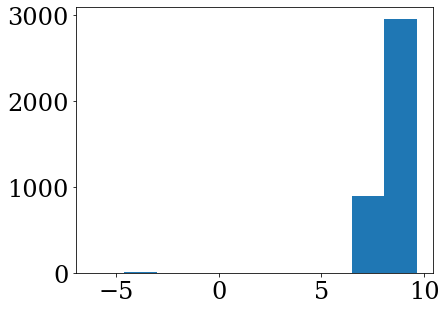

In [ ]:
plt.hist(coldmasks[:,0])